In [1]:
import pandas as pd

import os
from dotenv import load_dotenv
from sqlalchemy import create_engine

import plotly.express as px

In [2]:
load_dotenv()

def get_engine():
    """Return SQLAlchemy engine using .env credentials."""
    host = os.getenv("DB_HOST", "localhost")
    port = os.getenv("DB_PORT", "5432")
    user = os.getenv("DB_USER", "luis")
    password = os.getenv("DB_PASSWORD", "")
    dbname = os.getenv("DB_NAME", "power_consumption")
    
    return create_engine(f"postgresql+psycopg2://{user}:{password}@{host}:{port}/{dbname}")

engine = get_engine()

### read in sql views ###

In [ ]:
"""
Lädt die aggregierten Tages- und Stundendaten aus den Views
'daily_consumption' und 'hourly_consumption' in je einen DataFrame.
"""

df_daily = pd.read_sql("SELECT * FROM daily_consumption", engine)
df_hourly = pd.read_sql("SELECT * FROM hourly_consumption", engine)

In [ ]:
"""
Erstellt zwei Diagramme: einen Linienplot des täglichen Gesamtverbrauchs (total_power)
und ein Balkendiagramm des stündlichen Spitzenverbrauchs (peak_power).
"""

daily_line_chart = px.line(df_daily, x="day", y="total_power",
              title="Daily Power Consumption")

hourly_line_chart = px.bar(df_hourly, x="hour", y="peak_power",
                title="Hourly Power Consuption")

rolling average of daily consumtion

In [ ]:
"""
Berechnet den gleitenden 7-Tage-Durchschnitt des Gesamtverbrauchs
und stellt ihn zusammen mit dem täglichen Verbrauch im Linienplot dar.
"""

df_daily["rolling_7"] = df_daily["total_power"].rolling(7).mean()
px.line(df_daily, x="day", y=["total_power", "rolling_7"],
        title="Daily Consumption with 7-Day Rolling Average")

anomaly detection in daily consumption

In [ ]:
"""
Erkennt Ausreißer im täglichen Verbrauch via Z-Score (Schwellenwert ±2 Standardabweichungen)
und markiert diese als Anomalien im Scatterplot.
"""

df_daily["zscore"] = (df_daily["total_power"] - df_daily["total_power"].mean()) / df_daily["total_power"].std()
df_daily["anomaly"] = df_daily["zscore"].abs() > 2
px.scatter(df_daily, x="day", y="total_power", color="anomaly",
           title="Anomaly Detection in Daily Consumption")

average power by hour

In [ ]:
"""
Lädt das stündliche Verbrauchsmuster aus dem View 'hourly_pattern'
und zeigt den durchschnittlichen Verbrauch pro Tagesstunde als Linienplot.
"""

df_hour_pattern = pd.read_sql("SELECT * FROM hourly_pattern", engine)

px.line(df_hour_pattern,x="hour",y="avg_power",
        title="Average Power Consumption by Hour")

avg power by weekday

In [ ]:
"""
Lädt das Wochentagsmuster aus dem View 'weekday_pattern'
und zeigt den durchschnittlichen Verbrauch pro Wochentag als Balkendiagramm.
"""

df_weekday = pd.read_sql("SELECT * FROM weekday_pattern", engine)

px.bar(df_weekday,x="weekday",y="avg_power",
       title="Average Power Consumption by Weekday")

seasonality

In [ ]:
"""
Lädt das Monatsmuster aus dem View 'monthly_pattern'
und zeigt den durchschnittlichen Verbrauch pro Monat als Linienplot – sichtbar als Saisonalität.
"""

df_month = pd.read_sql("SELECT * FROM monthly_pattern", engine)

px.line(df_month,x="month",y="avg_power",
        title="Seasonality by Month")

peak days

In [ ]:
"""
Lädt die 20 Tage mit dem höchsten Spitzenverbrauch aus dem View 'peak_days'
und stellt sie als Balkendiagramm dar.
"""

df_peaks = pd.read_sql("SELECT * FROM peak_days", engine)

px.bar(df_peaks,x="day",y="peak_power",
       title="Top Peak Consumption Days")

distribution of energy

In [ ]:
"""
Lädt die Verbrauchsverteilung aus dem View 'submeter_distribution'
und stellt die Anteile der einzelnen Bereiche (Küche, Waschküche, Klima, Sonstiges) als Tortendiagramm dar.
"""

df_sub = pd.read_sql("SELECT * FROM submeter_distribution",engine)

px.pie(
    values=df_sub.iloc[0],
    names=df_sub.columns,
    title="Energy Consumption Distribution"
)

hidden energy chartline over time

In [ ]:
"""
Lädt den ungемessenen Verbrauch aus dem View 'hidden_consumption'
und zeigt den täglichen Verlauf des nicht zugeordneten Stromanteils als Linienplot.
"""

df_hidden = pd.read_sql("SELECT * FROM hidden_consumption",engine)

px.line(df_hidden,
        x="day",
        y="avg_hidden_energy",
        title="Hidden Energy Consumption Over Time")

In [ ]:
"""
Lädt die Tagesdaten aus 'daily_consumption' und benennt die Spalten
in das Prophet-Format um (ds = Datum, y = Zielwert).
"""

df = pd.read_sql("SELECT * FROM daily_consumption", engine)
df_prophet = df.rename(columns={
    "day": "ds",
    "total_power": "y"
})

## forcast with prophet ##

In [ ]:
from prophet import Prophet

"""
Initialisiert ein Prophet-Modell und trainiert es auf den täglichen Verbrauchsdaten.
"""

model = Prophet()

model.fit(df_prophet)

/Users/luis/Desktop/workdir/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
15:54:23 - cmdstanpy - INFO - Chain [1] start processing
15:54:25 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
"""
Erstellt einen 30-Tage-Forecast: generiert zukünftige Datumswerte
und berechnet die Vorhersage (inkl. Konfidenzintervall) mit dem trainierten Prophet-Modell.
"""

future = model.make_future_dataframe(periods=30)

forecast = model.predict(future)

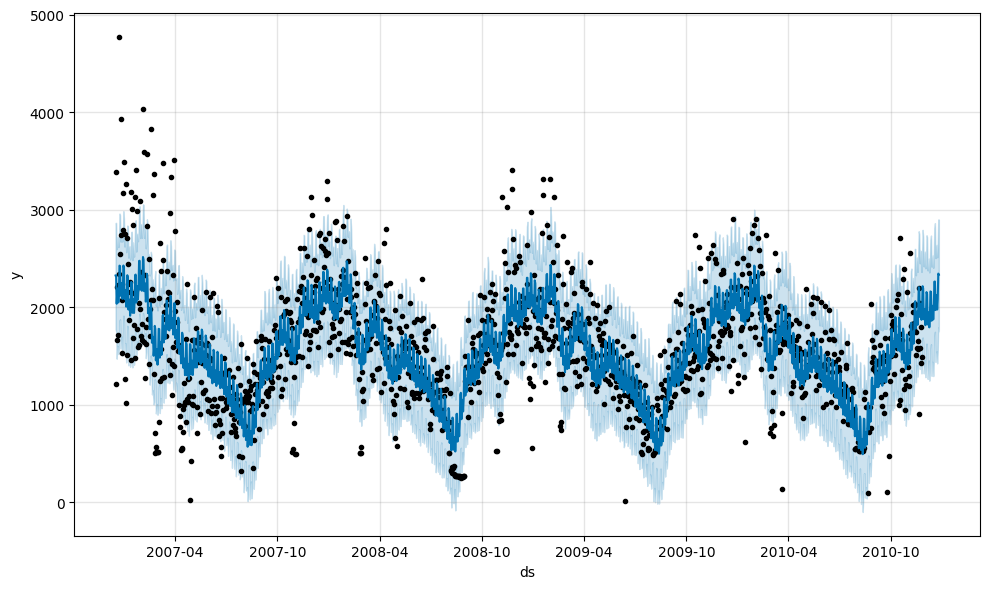

In [29]:
fig = model.plot(forecast)

power over the weekdays per heatmap

In [ ]:
"""
Lädt den durchschnittlichen Verbrauch je Stunde und Wochentag direkt aus 'power_features',
pivotiert die Daten zu einer Matrix und stellt sie als Heatmap dar (Achsen: Stunde × Wochentag).
"""

df_heat = pd.read_sql("""
    SELECT hour, weekday, AVG(global_active_power) AS avg_power
    FROM power_features
    GROUP BY hour, weekday
    ORDER BY weekday, hour
""", engine)

heat_pivot = df_heat.pivot(index="weekday", columns="hour", values="avg_power")
px.imshow(heat_pivot, title="Power Consumption Heatmap: Hour × Weekday",
          labels=dict(x="Hour", y="Weekday", color="kW"),
          color_continuous_scale="Reds")

correlation matrix for features

In [ ]:
"""
Lädt 100.000 Zeilen aus 'power_features', berechnet die Korrelationsmatrix
der wichtigsten Features und stellt sie als Heatmap dar.
"""

df_corr = pd.read_sql("SELECT * FROM power_features LIMIT 100000", engine)
corr = df_corr[["global_active_power","global_reactive_power","voltage",
                "sub_metering_1","sub_metering_2","sub_metering_3","unmetered_energy"]].corr()
px.imshow(corr, title="Feature Correlation Matrix", color_continuous_scale="RdBu")

categorical distribution over time

In [ ]:
"""
Lädt die monatliche Verbrauchsverteilung aus dem View 'submeter_monthly'
und stellt die Anteile der einzelnen Bereiche (Küche, Waschküche, Klima, Sonstiges) als Flächendiagramm dar.
"""

df_sub_monthly = pd.read_sql("SELECT * FROM submeter_monthly", engine)

# mit submeter_monthly View
px.area(df_sub_monthly, x="month", y=["kitchen","laundry","water_heater","other"],
        title="Submetering Distribution Over Time")

In [15]:
df_kpi = pd.read_sql("""
    SELECT
        ROUND(AVG(global_active_power)::numeric, 3) AS avg_power,
        ROUND(MAX(global_active_power)::numeric, 3) AS max_power,
        ROUND(SUM(global_active_power)::numeric, 0) AS total_power,
        ROUND(AVG(unmetered_energy)::numeric, 3) AS avg_hidden
    FROM power_features
""", engine)

## KPIs ##

In [ ]:
import plotly.graph_objects as go

"""
Erstellt ein KPI-Dashboard mit vier Kennzahlen (Durchschnitts-, Spitzen-, Gesamtverbrauch
und durchschnittlicher ungемessener Verbrauch) als nebeneinander dargestellte Indicator-Plots.
"""

fig_kpi = go.Figure()
kpi_labels = ["Avg Power (kW)", "Peak Power (kW)", "Total Power (kW)", "Avg Hidden (kW)"]
kpi_values = [
    round(df_kpi["avg_power"].iloc[0], 3),
    round(df_kpi["max_power"].iloc[0], 3),
    round(df_kpi["total_power"].iloc[0], 0),
    round(df_kpi["avg_hidden"].iloc[0], 3)
]

for i, (label, value) in enumerate(zip(kpi_labels, kpi_values)):
    fig_kpi.add_trace(go.Indicator(
        mode="number",
        value=value,
        title={"text": label},
        domain={"row": 0, "column": i}
    ))

fig_kpi.update_layout(
    grid={"rows": 1, "columns": 4},
    title="Key Performance Indicators"
)
fig_kpi.show()

In [18]:
df_eff = pd.read_sql("""
    SELECT DATE(timestamp) AS day,
        AVG(sub_metering_1 + sub_metering_2 + sub_metering_3) AS metered,
        AVG(unmetered_energy) AS unmetered,
        ROUND(CAST(AVG(sub_metering_1 + sub_metering_2 + sub_metering_3) /
            NULLIF(AVG(global_active_power * 1000 / 60), 0) * 100 AS numeric), 1) AS efficiency_pct
    FROM power_features
    GROUP BY DATE(timestamp)
    ORDER BY DATE(timestamp)
""", engine)

"Efficiency" over time

In [ ]:
"""
Zeigt die tägliche Metering-Effizienz (gemessener Anteil am Gesamtverbrauch) als Linienplot
mit einer gestrichelten Durchschnittslinie.
"""

fig_eff = px.line(df_eff, x="day", y="efficiency_pct",
                  title="Metering Efficiency Over Time (%)",
                  labels={"efficiency_pct": "Efficiency (%)", "day": "Date"})
fig_eff.add_hline(y=df_eff["efficiency_pct"].mean(), line_dash="dash",
                  annotation_text="Average", line_color="red")
fig_eff.show()

In [20]:
df_compare = pd.read_sql("""
    SELECT
        CASE 
            WHEN DATE(timestamp) >= (SELECT MAX(DATE(timestamp)) - INTERVAL '30 days' FROM power_features)
            THEN 'Letzte 30 Tage'
            ELSE 'Vorherige 30 Tage'
        END AS periode,
        AVG(global_active_power) AS avg_power
    FROM power_features
    WHERE DATE(timestamp) >= (SELECT MAX(DATE(timestamp)) - INTERVAL '60 days' FROM power_features)
    GROUP BY periode
""", engine)

compare 30 days avg power

In [ ]:
"""
Vergleicht den durchschnittlichen Verbrauch der letzten 30 Tage mit den vorherigen 30 Tagen
als farblich getrenntes Balkendiagramm.
"""

fig_compare = px.bar(df_compare, x="periode", y="avg_power",
                     title="Avg Power: Letzte 30 vs. Vorherige 30 Tage",
                     labels={"avg_power": "Avg Power (kW)", "periode": ""},
                     color="periode",
                     color_discrete_map={
                         "Letzte 30 Tage": "#636EFA",
                         "Vorherige 30 Tage": "#EF553B"
                     })
fig_compare.show()

In [21]:
df_peak_hour = pd.read_sql("""
    SELECT weekday, hour, AVG(global_active_power) AS avg_power
    FROM power_features
    GROUP BY weekday, hour
    ORDER BY weekday, avg_power DESC
""", engine)

heatmap peak hour per weekdays

In [ ]:
"""
Pivotiert die Verbrauchsdaten nach Stunde und Wochentag, benennt die Wochentage auf Deutsch
und stellt sie als Heatmap dar – zeigt Spitzenverbrauchszeiten je Wochentag.
"""

heat_pivot = df_peak_hour.pivot(index="weekday", columns="hour", values="avg_power")
heat_pivot.index = ["So", "Mo", "Di", "Mi", "Do", "Fr", "Sa"]

fig_peak_hour = px.imshow(heat_pivot,
                           title="Peak Hour pro Wochentag",
                           labels=dict(x="Stunde", y="Wochentag", color="kW"),
                           color_continuous_scale="Reds",
                           aspect="auto")
fig_peak_hour.show()

In [23]:
df_reactive = pd.read_sql("""
    SELECT DATE(timestamp) AS day,
        AVG(global_active_power) AS active,
        AVG(global_reactive_power) AS reactive,
        ROUND(CAST(AVG(global_reactive_power) / 
            NULLIF(AVG(global_active_power), 0) AS numeric), 3) AS power_factor
    FROM power_features
    GROUP BY DATE(timestamp)
    ORDER BY DATE(timestamp)
""", engine)

active vs reactive power

In [ ]:
"""
Stellt Wirk- und Blindleistung im Zeitverlauf als Linienplot dar
und zeigt den täglichen Power Factor (reactive/active) mit gestrichelter Durchschnittslinie.
"""

fig_reactive = px.line(df_reactive, x="day", y=["active", "reactive"],
                       title="Active vs. Reactive Power Over Time",
                       labels={"value": "Power (kW)", "day": "Date", "variable": "Type"})
fig_reactive.show()

fig_power_factor = px.line(df_reactive, x="day", y="power_factor",
                            title="Power Factor Over Time (reactive/active ratio)",
                            labels={"power_factor": "Power Factor", "day": "Date"})
fig_power_factor.add_hline(y=df_reactive["power_factor"].mean(), line_dash="dash",
                            annotation_text="Average", line_color="orange")
fig_power_factor.show()